In [15]:
import pandas as pd
from pygam import LinearGAM, s
import statsmodels.api as sm
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [16]:
# Create df
df_boston = pd.read_csv('./Data/boston_housing.csv')
df_boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [17]:
# We are trying to predict medv, so drop it from the predictors
X = df_boston.drop(columns=['medv'])
y = df_boston['medv']

n = X.shape[0]

In [18]:
# Add predictors
terms = s(0)
for i in range(1, X.shape[1]):
    terms = terms + s(i)

# Build GAM with predictors
gam = LinearGAM(terms).fit(X, y)

print(gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    103.2423
Link Function:                     IdentityLink Log Likelihood:                                 -1589.7653
Number of Samples:                          506 AIC:                                             3388.0152
                                                AICc:                                            3442.7649
                                                GCV:                                               13.7683
                                                Scale:                                              8.8269
                                                Pseudo R-Squared:                                   0.9168
Feature Function                  Lam

/var/folders/rn/hssbmm1178j2j4ms00vvyddm0000gn/T/ipykernel_36696/2572497908.py:9: UserWarning:

KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 




In [19]:
# Add constant for intercept
X_lr = sm.add_constant(X)
ols_model = sm.OLS(y, X_lr).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Fri, 10 Oct 2025   Prob (F-statistic):          6.72e-135
Time:                        16:37:28   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.000      26.432      46.487
crim          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
zn             0.0464      0.014      3.382      0.001       0.019       0.073
indus          0.0206      0.061      0.334      0.738      -0.100       0.141
chas           2.6867      0.862      3.118      0.002       0.994       4.380
nox          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
rm             3.8099      0.418      9.116      0.000       2.989       4.631
age            0.0007      0.013      0.052      0.958      -0.025       0.027
dis           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
rad            0.3060      0.066      4.613      0.000       0.176       0.436
tax           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
ptratio       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
b              0.0093      0.003      3.467      0.001       0.004       0.015
lstat         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [20]:
# Predictions OLS
y_pred_lr = ols_model.predict(X_lr)

lr_r2 = 0.741
lr_adjr2 = 0.734

p_lr = X.shape[1] + 1

# RSS for BIC
rss_lr = ((y - y_pred_lr)**2).sum()
bic_lr = n * np.log(rss_lr / n) + np.log(n) * p_lr

aic_lr = ols_model.aic


# Predictions GAM
y_pred_gam = gam.predict(X)

gam_r2 = 0.9168

# Effective degrees of freedom
edf = gam.statistics_['edof']
edf_total = edf if np.isscalar(edf) else sum(edf)

# Adjusted R^2
adj_r2_gam = 1 - (1 - gam_r2)*(n - 1)/(n - edf_total - 1)

# BIC approximation
rss_gam = ((y - y_pred_gam)**2).sum()
bic_gam = n * np.log(rss_gam / n) + np.log(n) * edf_total

# AIC and GCV from pyGAM
aic_gam = gam.statistics_['AIC']
gcv_gam = gam.statistics_['GCV']

print("GAM R^2:", gam_r2, "vs Linear Regression R^2:", lr_r2)
print("GAM Adjusted R^2:", adj_r2_gam, "vs Linear Regression Adjusted R^2:", lr_adjr2)
print("GAM BIC (approx):", bic_gam, "vs Linear Regression BIC:", bic_lr)
print("GAM AIC:", aic_gam, "vs Linear Regression AIC:", aic_lr)

GAM R^2: 0.9168 vs Linear Regression R^2: 0.741
GAM Adjusted R^2: 0.8954195638641427 vs Linear Regression Adjusted R^2: 0.734
GAM BIC (approx): 1629.33994935491 vs Linear Regression BIC: 1648.8143118424437
GAM AIC: 3388.015151425743 vs Linear Regression AIC: 3025.608594075548


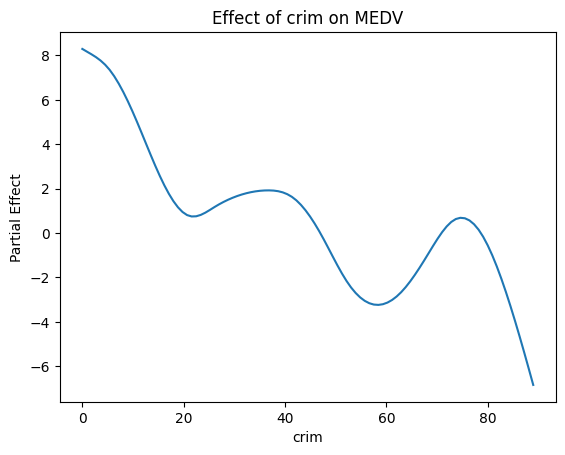

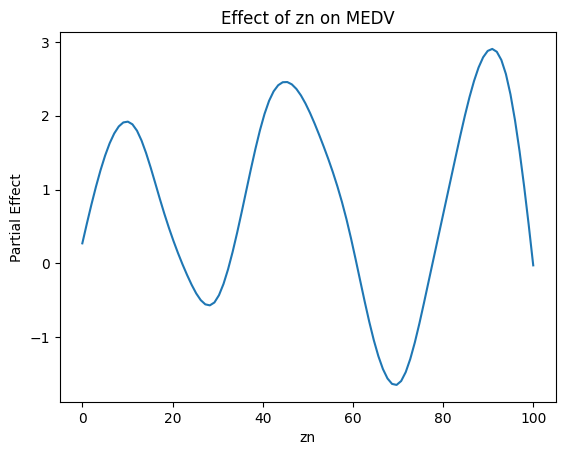

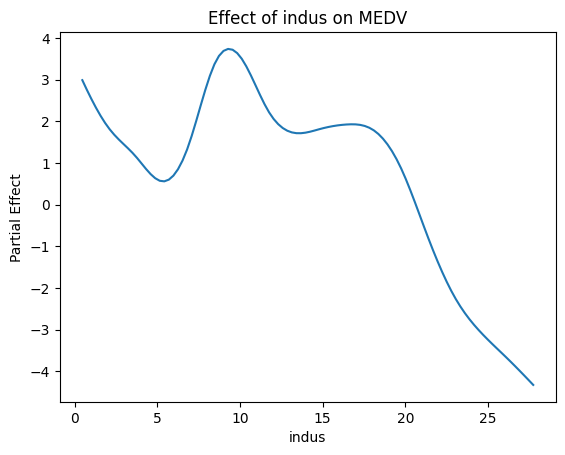

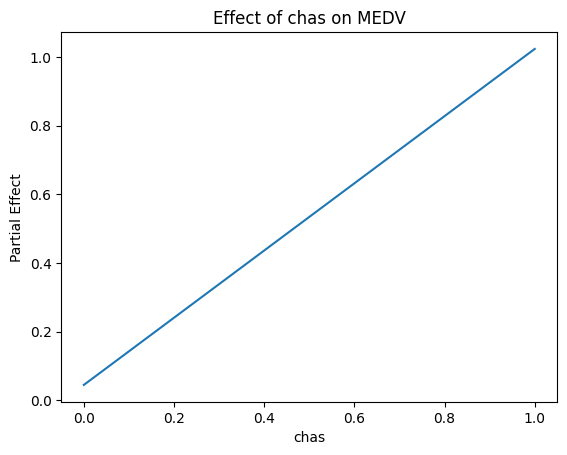

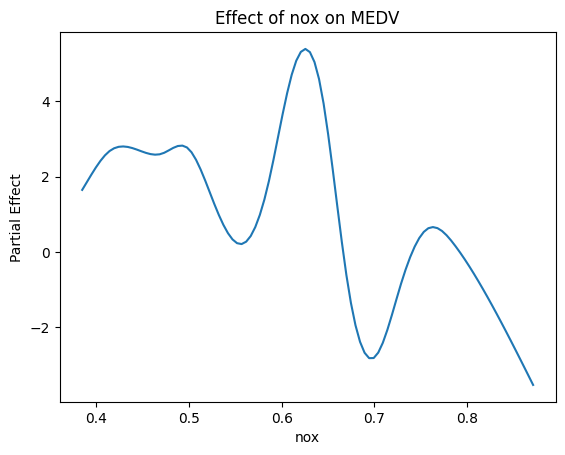

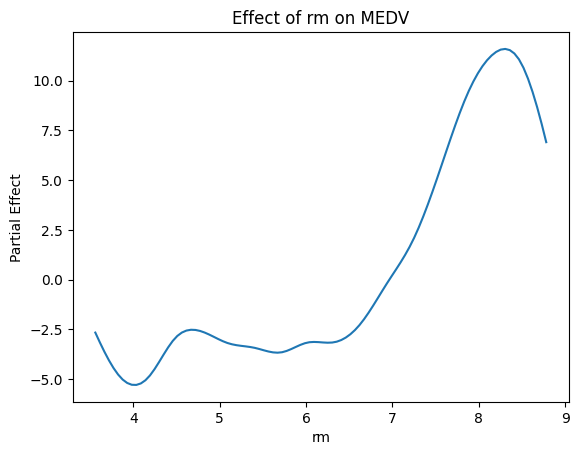

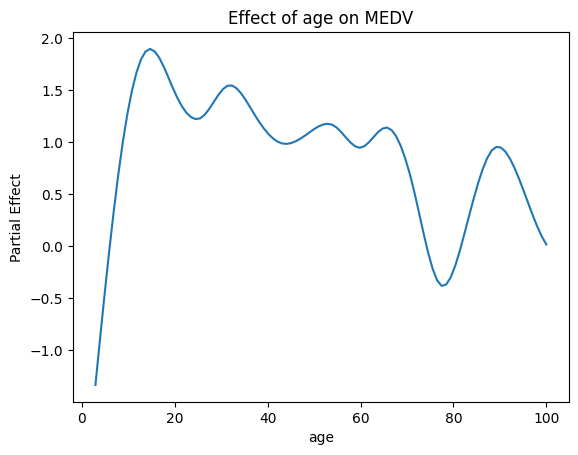

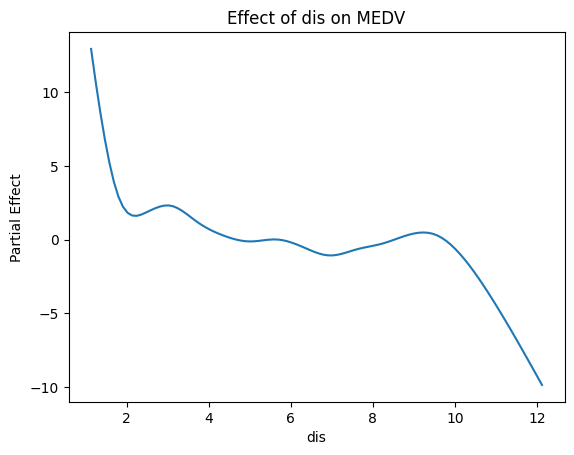

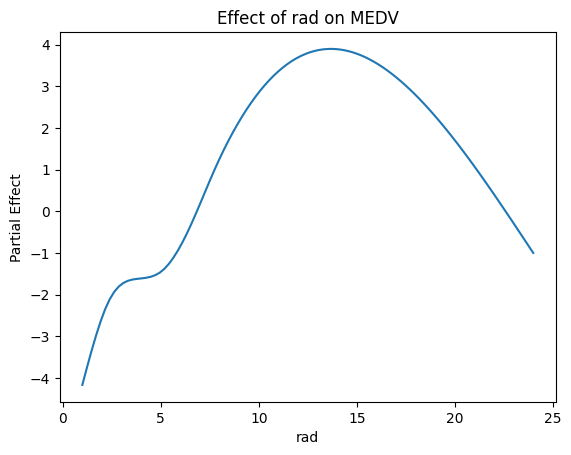

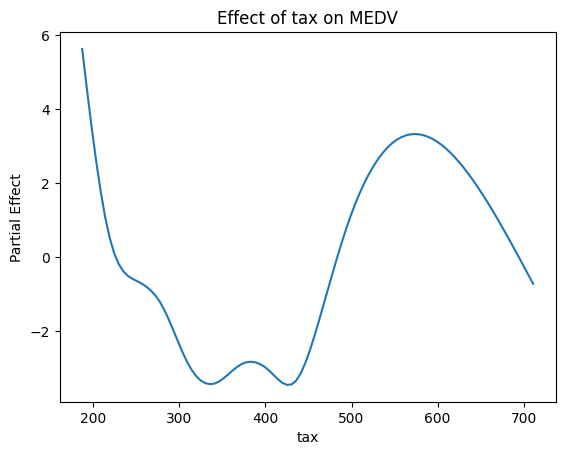

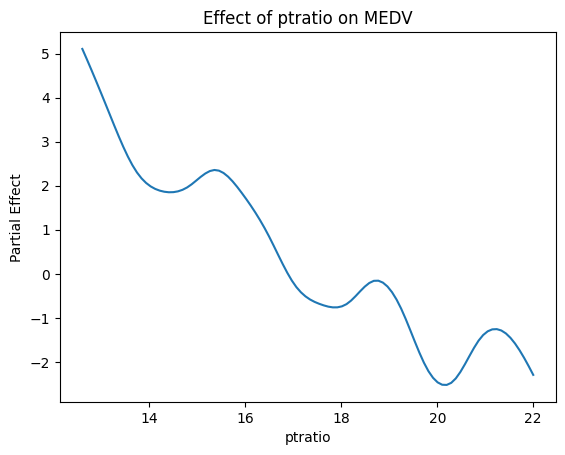

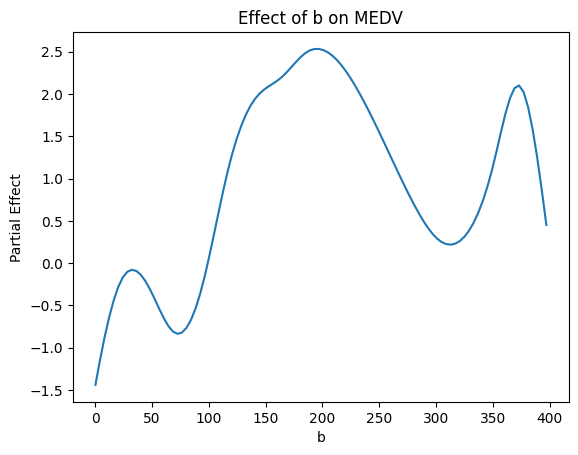

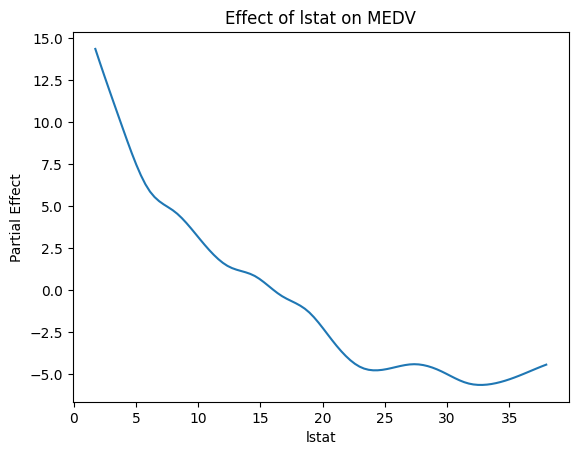

In [21]:
for i, col in enumerate(X.columns):
    XX = gam.generate_X_grid(term=i)
    plt.figure()
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.title(f"Effect of {col} on MEDV")
    plt.xlabel(col)
    plt.ylabel("Partial Effect")
    plt.show()


In [22]:
# Friendly names for predictors
friendly_labels = {
    'lstat': 'Lower Status in Neighborhood',
    'rm': 'Average Number of Rooms',
    'age': 'Proportion of Old Houses',
    'crim': 'Per Capita Crime Rate',
    'tax': 'Property Tax Rate',
    'ptratio': 'Pupil-Teacher Ratio',
    'nox': 'Nitric Oxide Concentration',
    'dis': 'Distance to Employment Centers',
    'indus': 'Proportion of Non-retail Business Acres',
    'zn': 'Residential Land Zoning',
    'b': 'Proportion of Black Residents',
    'chas': 'Bounds Charles River (0 = No, 1 = Yes)',
    'rad': 'Accessibility to Radial Highways Index'
}

predictors = X.columns.tolist()
n_predictors = len(predictors)

fig = go.Figure()

for i, predictor in enumerate(predictors):
    x_vals = np.linspace(X[predictor].min(), X[predictor].max(), 100)
    
    # Linear regression line for predictor
    beta_0 = ols_model.params[0]
    beta_i = ols_model.params[i+1]
    y_pred_lr_line = beta_0 + beta_i * x_vals
    
    # GAM smooth for predictor
    X_grid = X.mean().values.reshape(1, -1).repeat(100, axis=0)
    X_grid[:, i] = x_vals
    y_pred_gam_line = gam.predict(X_grid)
    
    # Scatter points (actual house prices)
    fig.add_trace(go.Scatter(
        x=X[predictor],
        y=y,
        mode='markers',
        name='Actual Prices',
        visible=(i==0),
        marker=dict(color='lightgrey'),
        hovertemplate=f'{friendly_labels.get(predictor,predictor)}: %{{x}}<br>Price: $%{{y}}k'
    ))
    
    # Linear regression line
    fig.add_trace(go.Scatter(
        x=x_vals,
        y=y_pred_lr_line,
        mode='lines',
        name='Simple Linear Prediction',
        visible=(i==0),
        line=dict(color='blue', width=3)
    ))
    
    # GAM smooth line
    fig.add_trace(go.Scatter(
        x=x_vals,
        y=y_pred_gam_line,
        mode='lines',
        name='Flexible Prediction',
        visible=(i==0),
        line=dict(color='red', width=3)
    ))

# Dropdown menu
buttons = []
for i, predictor in enumerate(predictors):
    visible = [False] * n_predictors * 3
    visible[i*3:i*3+3] = [True, True, True]

    # Friendly display name for title/axes
    display_name = friendly_labels.get(predictor, predictor)
    
    buttons.append(dict(
        label=predictor.lower(),
        method='update',
        args=[
            {'visible': visible},
            {'title': f"House Price vs {display_name}",
             'xaxis': {'title': display_name},
             'yaxis': {'title': 'House Price ($1000s)'}}
        ]
    ))


fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.05,
        y=1,
        xanchor='right',
        yanchor='top'
    )],
    title=f"House Price vs {friendly_labels.get(predictors[0], predictors[0])}",
    xaxis_title=friendly_labels.get(predictors[0], predictors[0]),
    yaxis_title="House Price ($1000s)",
    legend=dict(
        x=0.02,
        y=0.999,
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='black',
        borderwidth=1
    ),
    width=900,
    height=600
)

fig.show()

/var/folders/rn/hssbmm1178j2j4ms00vvyddm0000gn/T/ipykernel_36696/2192025124.py:27: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/rn/hssbmm1178j2j4ms00vvyddm0000gn/T/ipykernel_36696/2192025124.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



------

# **Linear regression vs Nonparametric Regression**

Motivation for GAM's

Nonparametric regression is when there are infinite-dimensional parameters. A key part of this is through the smoothing function. A smoothing function is when the parameters don’t necessarily have a specific functional form, so it’s used as a way to estimate these relationships. The relationships are often non-linear, so having a way to model non-linear relationships is vital. In the real world, it’s challenging to find linear relationships given how much is out of our control. There are too many outside variables and inconsistencies that come into play. So, how do we proceed? 

One way is through a Generalized Additive Model, or for short, a GAM. This is a common approach to being able to capture nonlinear relationships. It uses the aforementioned smoothing functions to better understand the data. Complex patterns are present throughout, so this approach allows for them to be seen.

GAM’s vs OLS

For this deep dive, we’ll be using a Boston housing dataset. The goal is to predict the median housing value (MEDV) from a variety of predictor variables. To list a few, there’s the property tax rate, per capita crime rate, and proportion of old houses, and much more. 

In [23]:
# Create df
df_boston = pd.read_csv('./Data/boston_housing.csv')
df_boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [24]:
# We are trying to predict medv, so drop it from the predictors
X = df_boston.drop(columns=['medv'])
y = df_boston['medv']

n = X.shape[0]

In [25]:
# Add predictors
terms = s(0)
for i in range(1, X.shape[1]):
    terms = terms + s(i)

# Build GAM with predictors
gam = LinearGAM(terms).fit(X, y)

In [26]:
# Add constant for intercept
X_lr = sm.add_constant(X)
ols_model = sm.OLS(y, X_lr).fit()

The next steps are to fit the respective models. After fitting, we then predict and go on to analyze some key values for a potential model selection. The values we’ll be looking at are R^2, Adjusted R^2, BIC, and AIC It’s important to note that comparing the two models in some aspects can be challenging, and specifically for GAMs due to their infinite parameter set. For OLS, it’s a bit simpler to look at a value like AIC because we know the exact number of coefficients. However, with GAMs, we need things like effective degrees of freedom, splines, and penalties. 

In [27]:
# Predictions OLS
y_pred_lr = ols_model.predict(X_lr)

lr_r2 = 0.741
lr_adjr2 = 0.734

p_lr = X.shape[1] + 1

# RSS for BIC
rss_lr = ((y - y_pred_lr)**2).sum()
bic_lr = n * np.log(rss_lr / n) + np.log(n) * p_lr

aic_lr = ols_model.aic


# Predictions GAM
y_pred_gam = gam.predict(X)

gam_r2 = 0.9168

# Effective degrees of freedom
edf = gam.statistics_['edof']
edf_total = edf if np.isscalar(edf) else sum(edf)

# Adjusted R^2
adj_r2_gam = 1 - (1 - gam_r2)*(n - 1)/(n - edf_total - 1)

# BIC approximation
rss_gam = ((y - y_pred_gam)**2).sum()
bic_gam = n * np.log(rss_gam / n) + np.log(n) * edf_total

# AIC and GCV from pyGAM
aic_gam = gam.statistics_['AIC']
gcv_gam = gam.statistics_['GCV']

print("GAM R^2:", gam_r2, "vs OLS R^2:", lr_r2)
print("GAM Adjusted R^2:", adj_r2_gam, "vs OLS Adjusted R^2:", lr_adjr2)
print("GAM BIC (approx):", bic_gam, "vs OLS BIC:", bic_lr)
print("GAM AIC:", aic_gam, "vs OLS AIC:", aic_lr)

GAM R^2: 0.9168 vs OLS R^2: 0.741
GAM Adjusted R^2: 0.8954195638641427 vs OLS Adjusted R^2: 0.734
GAM BIC (approx): 1629.33994935491 vs OLS BIC: 1648.8143118424437
GAM AIC: 3388.015151425743 vs OLS AIC: 3025.608594075548


In analyzing the above results, we can see that GAM are favored in terms of R^2, Adjusted R^2, and BIC. However, OLS wins for AIC. Why might this be? The GAM has a large effective degrees of freedom count, potentially offsetting the log likelihood improvement. The AIC vs BIC results are somewhat surprising, but from the overall results, GAM is favored. 

To further dive into this, let’s create an interactive Plotly visualization! For each predictor, we plot the actual data points of the observed house prices vs that predictor, the linear regression prediction, and the GAM prediction. 

In [28]:
# Friendly names for predictors
friendly_labels = {
    'lstat': 'Lower Status in Neighborhood',
    'rm': 'Average Number of Rooms',
    'age': 'Proportion of Old Houses',
    'crim': 'Per Capita Crime Rate',
    'tax': 'Property Tax Rate',
    'ptratio': 'Pupil-Teacher Ratio',
    'nox': 'Nitric Oxide Concentration',
    'dis': 'Distance to Employment Centers',
    'indus': 'Proportion of Non-retail Business Acres',
    'zn': 'Residential Land Zoning',
    'b': 'Proportion of Black Residents',
    'chas': 'Bounds Charles River (0 = No, 1 = Yes)',
    'rad': 'Accessibility to Radial Highways Index'
}

predictors = X.columns.tolist()
n_predictors = len(predictors)

fig = go.Figure()

for i, predictor in enumerate(predictors):
    x_vals = np.linspace(X[predictor].min(), X[predictor].max(), 100)
    
    # Linear regression line for predictor
    beta_0 = ols_model.params[0]
    beta_i = ols_model.params[i+1]
    y_pred_lr_line = beta_0 + beta_i * x_vals
    
    # GAM smooth for predictor
    X_grid = X.mean().values.reshape(1, -1).repeat(100, axis=0)
    X_grid[:, i] = x_vals
    y_pred_gam_line = gam.predict(X_grid)
    
    # Scatter points (actual house prices)
    fig.add_trace(go.Scatter(
        x=X[predictor],
        y=y,
        mode='markers',
        name='Actual Prices',
        visible=(i==0),
        marker=dict(color='lightgrey'),
        hovertemplate=f'{friendly_labels.get(predictor,predictor)}: %{{x}}<br>Price: $%{{y}}k'
    ))
    
    # Linear regression line
    fig.add_trace(go.Scatter(
        x=x_vals,
        y=y_pred_lr_line,
        mode='lines',
        name='Simple Linear Prediction',
        visible=(i==0),
        line=dict(color='blue', width=3)
    ))
    
    # GAM smooth line
    fig.add_trace(go.Scatter(
        x=x_vals,
        y=y_pred_gam_line,
        mode='lines',
        name='Flexible Prediction',
        visible=(i==0),
        line=dict(color='red', width=3)
    ))

# Dropdown menu
buttons = []
for i, predictor in enumerate(predictors):
    visible = [False] * n_predictors * 3
    visible[i*3:i*3+3] = [True, True, True]

    # Friendly display name for title/axes
    display_name = friendly_labels.get(predictor, predictor)
    
    buttons.append(dict(
        label=predictor.lower(),
        method='update',
        args=[
            {'visible': visible},
            {'title': f"House Price vs {display_name}",
             'xaxis': {'title': display_name},
             'yaxis': {'title': 'House Price ($1000s)'}}
        ]
    ))


fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=1.05,
        y=1,
        xanchor='right',
        yanchor='top'
    )],
    title=f"House Price vs {friendly_labels.get(predictors[0], predictors[0])}",
    xaxis_title=friendly_labels.get(predictors[0], predictors[0]),
    yaxis_title="House Price ($1000s)",
    legend=dict(
        x=0.02,
        y=0.999,
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='black',
        borderwidth=1
    ),
    width=900,
    height=600
)

fig.show()

/var/folders/rn/hssbmm1178j2j4ms00vvyddm0000gn/T/ipykernel_36696/2192025124.py:27: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/var/folders/rn/hssbmm1178j2j4ms00vvyddm0000gn/T/ipykernel_36696/2192025124.py:28: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



From the visualizations, we can see some quite similar plots and very different ones. Some predictors with similar blue and red lines are lower status in neighborhood, pupil-teacher ratio, proportion of black residents, and more. The similar ones suggest that there is a linear relationship and that perhaps we should stick with OLS, whereas the others indicate that a GAM is better. One interesting plot that stands out is the age of the house. Does the age not impact the price that much? Maybe, given how there can be an old fixer-upper, or conversely, a Painted Lady. 

Tradeoffs

So, when should we go with linear regression vs something nonparametric, like a GAM, and vice versa? Like all situations…it depends. With linear regression, it’s much simpler to understand and interpret. There are clear values in regards to each predictor and how much they will impact the outcome. However, again, they are less flexible and can miss nonlinear relationships. Big patterns and curves can be missed, but if you’re expecting linear relationships, the choice is most likely OLS.

For GAMs, a big plus is flexibility. Nonlinear relationships are captured, resulting in better predictions for a lot of real-world situations. However, some big downfalls are interpretability and communication. There isn’t a direct slope or number for each predictor you can point to, indicating how this particular variable affects the outcome. For non-technical audiences that you may be working with, getting your point across becomes a bigger challenge.

Overall, there are a variety of pros and cons for each type of model. Linear regression models are easier to interpret and understand, but the ability to capture more complex, nonlinear relationships is decreased. Conversely, nonparametric models can have increased accuracy, but are more challenging to interpret and communicate. Deciding which route to go ultimately depends on the domain, your team, and the situation. 